<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/Copia_de_Laberinto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laberinto**

**Objetivo**

**Ejercicio**
En ausencia de aprendizaje, una rata en un laberinto se mueve aleatoriamente. Si hay $k$ formas de abandonar un laberinto, elije una salida con probabilidad $1/k$. ¿Cuál es la probabilidad de que la ratas encuentre primero la comida antes que el electroshock en el siguiente laberinto?

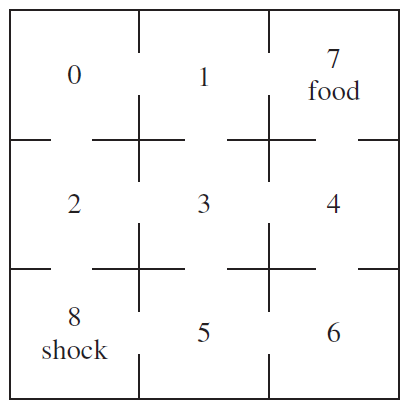




Definimos los estados:



*   Estado 0: punto de incio
*   Estado 1: punto de unión de $A(PA)$
*   Estado 2: punto de inicio
*   Estado 3:
*   Estado 4:



**ANALITICAMENTE SE TIENE:**

Si el tiempo $n$ un raton esta en un cuarto con $k$ habitaciones (adyacentes), elije una de ellas con probabilidad $\frac{1}{k}$

¿Cuál es la probabilidad de que el ratón, iniciando  en la casilla 0, alcance la comida?


**DIAGRAMA DE TRANSICION**

In [1]:
#librerias
import matplotlib.pyplot as plt
import networkx as nx
import sympy as sp

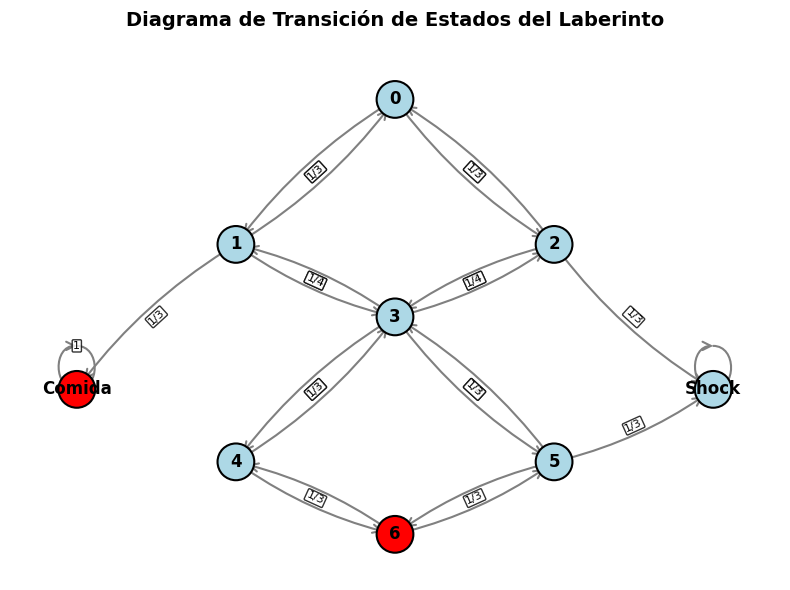

In [15]:
import matplotlib.pyplot as plt
import networkx as nx
import sympy as sp

# Define la matriz de transición 'matriz' con SymPy Rational para fracciones
matriz = sp.Matrix([
        [0, sp.Rational(1,2), sp.Rational(1,2), 0, 0, 0, 0, 0, 0],
    [sp.Rational(1,3), 0, 0, sp.Rational(1,3), 0, 0, 0, sp.Rational(1,3), 0],
    [sp.Rational(1,3), 0, 0, sp.Rational(1,3), 0, 0, 0, 0, sp.Rational(1,3)],
    [0, sp.Rational(1,4), sp.Rational(1,4), 0, sp.Rational(1,4), sp.Rational(1,4), 0, 0, 0],
    [0, 0, 0, sp.Rational(1,3), 0, 0, sp.Rational(1,3), sp.Rational(1,3), 0],
    [0, 0, 0, sp.Rational(1,3), 0, 0, sp.Rational(1,3), 0, sp.Rational(1,3)],
    [0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, sp.Rational(1,2), 0, 0, sp.Rational(1,2), 0, 0, 0]
])

# Configurar la visualización
plt.figure(figsize=(8, 6))

# Crear el grafo (Dirigido, ya que las transiciones tienen dirección)
G = nx.DiGraph() # Inicializa el objeto grafo

# Definir los nodos del laberinto (del 0 al 8)
# Los estados 7 (Comida) y 8 (Electroshock) son absorbentes
nodes = list(range(9))
G.add_nodes_from(nodes)

# Añadir aristas con las probabilidades de transición
# (u, v, probabilidad)
# Estado 0 (inicio)
G.add_edge(0, 1, label=matriz[0,1])
G.add_edge(0, 2, label=matriz[0,2])

# Estado 1 (Junction A)
G.add_edge(1, 0, label=matriz[1,0])
G.add_edge(1, 3, label=matriz[1,3])
G.add_edge(1, 7, label=matriz[1,7]) # A comida

# Estado 2 (Junction B)
G.add_edge(2, 0, label=matriz[2,0])
G.add_edge(2, 3, label=matriz[2,3])
G.add_edge(2, 8, label=matriz[2,8]) # A electroshock

# Estado 3 (Junction C)
G.add_edge(3, 1, label=matriz[3,1])
G.add_edge(3, 2, label=matriz[3,2])
G.add_edge(3, 4, label=matriz[3,4])
G.add_edge(3, 5, label=matriz[3,5])

# Estado 4 (Junction D)
G.add_edge(4, 3, label=matriz[4,3])
G.add_edge(4, 6, label=matriz[4,6])

# Estado 5 (Junction E)
G.add_edge(5, 3, label=matriz[5,3])
G.add_edge(5, 6, label=matriz[5,6])
G.add_edge(5, 8, label=matriz[5,8]) # A electroshock

# Estado 6 (Junction F)
G.add_edge(6, 4, label=matriz[6,4])
G.add_edge(6, 5, label=matriz[6,5])

# Estados absorbentes (ya definidos en la matriz, pero se pueden añadir para claridad visual)
G.add_edge(7, 7, label=matriz[7,7]) # Comida se mantiene en comida
G.add_edge(8, 8, label=matriz[8,8]) # Electroshock se mantiene en electroshock

# Posición de los nodos para una visualización clara (ajusta según la imagen del laberinto)
pos = {
    0: (0, 3), # Inicio
    1: (-1, 2), # PA
    2: (1, 2), # PB
    3: (0, 1.5), # PC
    4: (-1, 0.5), # PD
    5: (1, 0.5), # PE
    6: (0, 0), # PF
    7: (-2, 1), # Comida
    8: (2, 1)  # Electroshock
}

# Dibujar nodos
# Colorear estados 6 y 7 (absorbentes) de rojo, y el resto (transitorios) de azul claro
nx.draw_networkx_nodes(G, pos,
                      node_color=['red' if n in [6, 7] else 'lightblue' for n in G.nodes()],
                      node_size=700,
                      edgecolors='black',
                      linewidths=1.5)

# Dibujar aristas con flechas simples ->
nx.draw_networkx_edges(G, pos,
                      arrows=True,
                      arrowstyle='->',
                      arrowsize=15,
                      width=1.5,
                      edge_color='gray',
                      connectionstyle='arc3,rad=0.1')

# Etiquetas de los nodos
nx.draw_networkx_labels(G, pos,
                       labels={n: str(n) if n not in [7,8] else ('Comida' if n==7 else 'Shock') for n in G.nodes()},
                       font_size=12,
                       font_weight='bold')

# Etiquetas de las aristas (probabilidades)
edge_labels = {(u, v): f'{d["label"]}' for u, v, d in G.edges(data=True) if d['label'] > 0}
nx.draw_networkx_edge_labels(G, pos,
                            edge_labels=edge_labels,
                            font_size=8,
                            bbox=dict(boxstyle='round,pad=0.1',
                                     facecolor='white',
                                     alpha=0.8))

plt.title('Diagrama de Transición de Estados del Laberinto', fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

---
### Paso 1. Clasificación de Estados

*   **Estados Absorbentes:** Son aquellos estados en los que, una vez que se entra, no se puede salir (P(i,i)=1). En este laberinto, según la matriz de transición proporcionada, los estados absorbentes son:
    *   **Estado 6**
    *   **Estado 7: Comida (Food)**

*   **Estados Transitorios:** Son los estados desde los que se puede pasar a otros estados (incluyendo estados absorbentes) y de los que es posible salir. En este laberinto, los estados transitorios son:
    *   **Estados 0, 1, 2, 3, 4, 5, 8**

La matrizde Transicion

In [3]:
#librerias
import numpy as np
from sympy import Matrix , init_printing
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt

In [9]:
matriz = sp.Matrix([
        [0, sp.Rational(1,2), sp.Rational(1,2), 0, 0, 0, 0, 0, 0],
    [sp.Rational(1,3), 0, 0, sp.Rational(1,3), 0, 0, 0, sp.Rational(1,3), 0],
    [sp.Rational(1,3), 0, 0, sp.Rational(1,3), 0, 0, 0, 0, sp.Rational(1,3)],
    [0, sp.Rational(1,4), sp.Rational(1,4), 0, sp.Rational(1,4), sp.Rational(1,4), 0, 0, 0],
    [0, 0, 0, sp.Rational(1,3), 0, 0, sp.Rational(1,3), sp.Rational(1,3), 0],
    [0, 0, 0, sp.Rational(1,3), 0, 0, sp.Rational(1,3), 0, sp.Rational(1,3)],
    [0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, sp.Rational(1,2), 0, 0, sp.Rational(1,2), 0, 0, 0]
])

print("Matriz de Transición de P:")

Matriz de Transición de P:


In [10]:
matriz

Matrix([
[                0,  0.5,  0.5,                 0,    0,    0,                 0,                 0,                 0],
[0.333333333333333,    0,    0, 0.333333333333333,    0,    0,                 0, 0.333333333333333,                 0],
[0.333333333333333,    0,    0, 0.333333333333333,    0,    0,                 0,                 0, 0.333333333333333],
[                0, 0.25, 0.25,                 0, 0.25, 0.25,                 0,                 0,                 0],
[                0,    0,    0, 0.333333333333333,    0,    0, 0.333333333333333, 0.333333333333333,                 0],
[                0,    0,    0, 0.333333333333333,    0,    0, 0.333333333333333,                 0, 0.333333333333333],
[                0,    0,    0,                 0,    0,    0,                 1,                 0,                 0],
[                0,    0,    0,                 0,    0,    0,                 0,                 1,                 0],
[                0,    

2. Ordenamos la matriz para forma estándar absorbente

Reordenamos: $T = [0,1,2,3,4,5,8]$, luego $ F = [6,7] $.

La matriz $ P $ tiene bloques:

$$
P = \begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}
$$

Donde:

* $ Q $ : de transitorios a transitorios (7×7)  
* $ R$ : de transitorios a absorbentes (7×2)  
*  $I$ : identidad 2×2 para 6 y 7.

Construyamos $Q$ y $R$.

**Fila 0:** $[0,\frac{1}{2},\frac{1}{2},0,0,0,0,0,0]$
$\rightarrow$ solo va a ${1,2}$ (transitorios)

$
Q[0,1]=\frac{1}{2}, \quad
Q[0,2]=\frac{1}{2}, \quad
R=0
$

**Fila 1:** $[\frac{1}{3},0,0,\frac{1}{3},0,0,0,\frac{1}{3},0]$

Va a ${0,3,7}$:
* col7 $=\frac13$ es absorbente 7
* col0 $=\frac13$
* col3 $=\frac13$

En $Q$: col0 (0) y col3 (3).

En $R$: col7 (absorbente 7) $=\frac13$.

Índices locales:

$
Q[1,0]=\frac13
$

$
Q[1,3]=\frac13
$

$
R[1,1]=\frac13
$

porque el absorbente 7 es índice 1 en $F$
(6 $\rightarrow$ índice 0, 7 $\rightarrow$ índice 1).


**Fila 2:** $[\frac13,0,0,\frac13,0,0,0,0,\frac13]$

Va a ${0,3,8}$ $\rightarrow$ todos transitorios.

$
Q[2,0]=\frac13, \quad
Q[2,3]=\frac13, \quad
Q[2,8]=\frac13
$

$
R=0
$

**Fila 3:** $[0,\frac14,\frac14,0,\frac14,\frac14,0,0,0]$

Va a ${1,2,4,5}$ $\rightarrow$ todos transitorios.

$
Q[3,1]=\frac14,\quad
Q[3,2]=\frac14,\quad
Q[3,4]=\frac14,\quad
Q[3,5]=\frac14
$

$
R=0
$

**Fila 4:** $[0,0,0,\frac13,0,0,\frac13,\frac13,0]$

Va a ${3,6,7}$:
* a 6 (absorbente índice 0)
* a 7 (absorbente índice 1)

$
Q[4,3]=\frac13
$

$
R[4,0]=\frac13,
\quad
R[4,1]=\frac13
$



**Fila 5:** $[0,0,0,\frac13,0,0,\frac13,0,\frac13]$

Va a ${3,6,8}$.

$
Q[5,3]=\frac13,
\quad
Q[5,8]=\frac13,
\quad
R[5,0]=\frac13
$



**Fila 8:** $[0,0,\frac12,0,0,\frac12,0,0,0]$

Va a ${2,5}$.

$
Q[8,2]=\frac12,
\quad
Q[8,5]=\frac12
$

$
R=0
$

In [13]:
transient_states = [0, 1, 2, 3, 4, 5, 8]
absorbing_states = [6, 7]

# Extraer Q (de transitorios a transitorios)
Q_rows = [matriz.row(i) for i in transient_states]
Q_matrix = sp.Matrix([list(row[j] for j in transient_states) for row in Q_rows])

# Extraer R (de transitorios a absorbentes)
R_rows = [matriz.row(i) for i in transient_states]
R_matrix = sp.Matrix([list(row[j] for j in absorbing_states) for row in R_rows])

# Extraer 0 (de absorbentes a transitorios)
Zero_rows = [matriz.row(i) for i in absorbing_states]
Zero_matrix = sp.Matrix([list(row[j] for j in transient_states) for row in Zero_rows])

# Extraer I (de absorbentes a absorbentes)
I_rows = [matriz.row(i) for i in absorbing_states]
I_matrix = sp.Matrix([list(row[j] for j in absorbing_states) for row in I_rows])

print("Matriz Q:")
display(Q_matrix)
print("\nMatriz R:")
display(R_matrix)
print("\nMatriz Cero (Absorbente a Transitorio):")
display(Zero_matrix)
print("\nMatriz I (Absorbente a Absorbente):")
display(I_matrix)

Matriz Q:


Matrix([
[  0, 1/2, 1/2,   0,   0,   0,   0],
[1/3,   0,   0, 1/3,   0,   0,   0],
[1/3,   0,   0, 1/3,   0,   0, 1/3],
[  0, 1/4, 1/4,   0, 1/4, 1/4,   0],
[  0,   0,   0, 1/3,   0,   0,   0],
[  0,   0,   0, 1/3,   0,   0, 1/3],
[  0,   0, 1/2,   0,   0, 1/2,   0]])


Matriz R:


Matrix([
[  0,   0],
[  0, 1/3],
[  0,   0],
[  0,   0],
[1/3, 1/3],
[1/3,   0],
[  0,   0]])


Matriz Cero (Absorbente a Transitorio):


Matrix([
[0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0]])


Matriz I (Absorbente a Absorbente):


Matrix([
[1, 0],
[0, 1]])

Este código divide la matriz de transición en las submatrices canónicas de una cadena de Markov absorbente.

Primero se identifican los estados:

*   *Estados transitorios:* la rata puede salir de ellos y continuar moviéndose.
*   Elemento de lista

  
    \item \textbf{Estados absorbentes:} una vez que la rata llega a ellos, permanece ahí para siempre.

A partir de la matriz original se construyen cuatro submatrices:

\begin{itemize}
    \item \textbf{Matriz \(Q\):} contiene las probabilidades de transición entre estados transitorios.
    
    \item \textbf{Matriz \(R\):} contiene las probabilidades de pasar de estados transitorios a estados absorbentes.
    
    \item \textbf{Matriz \(0\):} representa las transiciones de estados absorbentes hacia transitorios. Todos sus elementos son cero.
    
    \item \textbf{Matriz \(I\):} representa las transiciones



entre estados absorbentes. Es una matriz identidad porque un estado absorbente permanece en sí mismo con probabilidad 1.
\end{itemize}

Finalmente, el programa usa la librería \texttt{sympy} para manejar las matrices y conservar los valores exactos en forma de fracciones.

¿Cuál es la probabilidad de que la ratas encuentre primero la comida antes que el electroshock en el siguiente laberinto?

Para ello, procedamos a utilizar las ecuaciones de balance  $π=(p_0)$ hasta $p_8$

In [11]:
# Definimos variables para p[0..8]
p0, p1, p2, p3, p4, p5, p6, p7, p8 = sp.symbols('p0 p1 p2 p3 p4 p5 p6 p7 p8')

# Ecuaciones
eq0 = sp.Eq(p0, (p1 + p2) / 2) # grado 2
eq1 = sp.Eq(p1, (p0 + 1 + p3) / 3) # p[7] = 1
eq2 = sp.Eq(p2, (p0 + p3 + p8) / 3) # grado 3
eq3 = sp.Eq(p3, (p1 + p2 + p4 + p5) / 4)# grado 4
eq4 = sp.Eq(p4, (1 + p3 + 0) / 3) # p[7] = 1, p[6] = 0
eq5 = sp.Eq(p5, (p8 + p3 + 0) / 3) # p[6] = 0
eq6 = sp.Eq(p6, 0) # p[7] = 1
eq7= sp.Eq(p7, 1) # p[6] = 0
eq8 = sp.Eq(p8, (p2 + p5) / 2) # grado 2

# Resolver
sol = sp.solve([eq0, eq1, eq2, eq3, eq4, eq5, eq6, eq7,  eq8],
               [p0, p1, p2, p3, p4, p5,p6, p7,  p8])

print("Solución:")
for var, val in sol.items():
    print(f"{var} = {val}")

# Si queremos la respuesta desde el nodo inicial (0):
print("\nProbabilidad desde nodo 0 (inicio):", sol[p0])


Solución:
p0 = 3/5
p1 = 7/10
p2 = 1/2
p3 = 1/2
p4 = 1/2
p5 = 3/10
p6 = 0
p7 = 1
p8 = 2/5

Probabilidad desde nodo 0 (inicio): 3/5


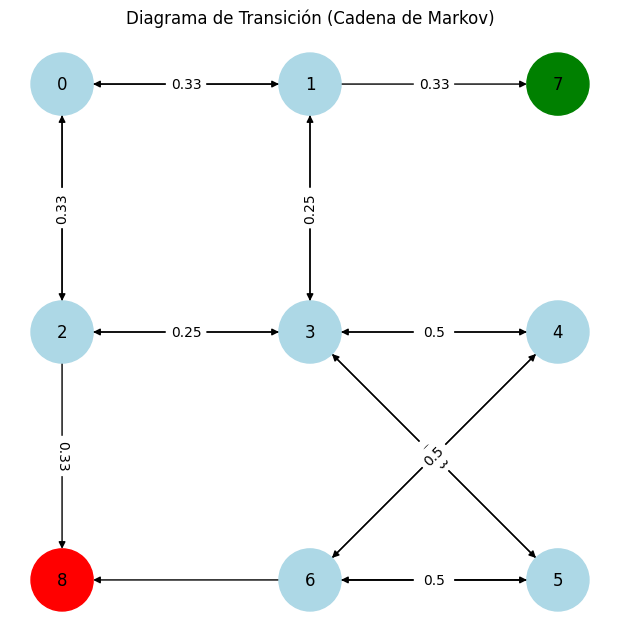

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

# Estados y vecinos (tu mismo modelo)
neighbors = {
    0:[1,2],
    1:[0,3,7],
    2:[0,3,8],
    3:[1,2,4,5],
    4:[3,6],
    5:[3,6,8],
    6:[4,5],
    7:[],  # absorbente (food)
    8:[]   # absorbente (shock)
}

# Crear grafo dirigido
G = nx.DiGraph()

# Agregar aristas con probabilidades
for s, nbs in neighbors.items():
    k = len(nbs)
    for nb in nbs:
        G.add_edge(s, nb, weight=round(1/k, 2))

# Posiciones (para que se vea como tu cuadrícula)
pos = {
    0:(0,2), 1:(1,2), 2:(0,1),
    3:(1,1), 4:(2,1), 5:(2,0),
    6:(1,0), 7:(2,2), 8:(0,0)
}

# Colores (absorventes distintos)
colors = []
for node in G.nodes():
    if node == 7:
        colors.append("green")   # comida
    elif node == 8:
        colors.append("red")     # shock
    else:
        colors.append("lightblue")

# Dibujar nodos y aristas
plt.figure(figsize=(6,6))
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000, font_size=12)

# Etiquetas de probabilidad
edge_labels = {(u,v): d['weight'] for u,v,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Diagrama de Transición (Cadena de Markov)")
plt.show()